# CanAI Cafe - EDA & Business Insights
**Owner:** Nikhil Khatri  
**Input:** `../data/clean/data_clean.csv`  
**Output:** charts saved to `../outputs/charts/`

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

sns.set_theme(style='whitegrid')
CHARTS_DIR = '../outputs/charts/'
os.makedirs(CHARTS_DIR, exist_ok=True)

## 1. Load Clean Data

In [2]:
df = pd.read_csv('../data/clean/data_clean.csv', parse_dates=['Transaction Date'])
print(f"Shape: {df.shape[0]} rows, {df.shape[1]} columns")
df.head()

Shape: 9483 rows, 10 columns


,Row_ID,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date,Province
0,1,TXN_9687814,Coffee,2,3.5,7.0,Digital Wallet,In-store,2023-09-28,British Columbia
1,2,TXN_7002925,Refresher,2,5.0,10.0,Cash,Unknown,2023-05-02,Newfoundland and Labrador
2,3,TXN_7668262,Donut,1,2.0,2.0,Digital Wallet,In-store,2023-11-27,British Columbia
3,4,TXN_9390285,Coffee,1,3.5,3.5,Unknown,Takeaway,2023-05-11,Newfoundland and Labrador
4,5,TXN_7321503,Tea,1,3.0,3.0,Credit Card,Takeaway,2023-09-15,British Columbia


### 1.1 Data Types

In [3]:
df.dtypes

Row_ID                       int64
Transaction ID                 str
Item                           str
Quantity                     int64
Price Per Unit             float64
Total Spent                float64
Payment Method                 str
Location                       str
Transaction Date    datetime64[us]
Province                       str
dtype: object

### 1.2 Nulls & "Unknown" Values

In [4]:
print("Null counts per column:")
print(df.isnull().sum())
print(f"\n'Unknown' counts per column:")
for col in df.select_dtypes(include='object').columns:
    unknown_count = (df[col] == 'Unknown').sum()
    if unknown_count > 0:
        pct = unknown_count / len(df) * 100
        print(f"  {col}: {unknown_count} ({pct:.1f}%)")

Null counts per column:
Row_ID              0
Transaction ID      0
Item                0
Quantity            0
Price Per Unit      0
Total Spent         0
Payment Method      0
Location            0
Transaction Date    0
Province            0
dtype: int64

'Unknown' counts per column:
  Payment Method: 524 (5.5%)
  Location: 832 (8.8%)
  Province: 396 (4.2%)


/var/folders/j9/p__0ry6s2gqdhm3jsd4f1d3h0000gn/T/ipykernel_29736/2366589100.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include='object').columns:


### 1.3 Summary Statistics

In [5]:
print(f"Total revenue: ${df['Total Spent'].sum():,.2f}")
print(f"Records: {len(df):,}")
print(f"Date range: {df['Transaction Date'].min().date()} to {df['Transaction Date'].max().date()}")
print(f"\nUnique values:")
print(f"  Items: {df['Item'].nunique()} - {sorted(df['Item'].unique())}")
print(f"  Locations: {df['Location'].nunique()} - {sorted(df['Location'].unique())}")
print(f"  Provinces: {df['Province'].nunique()} - {sorted(df['Province'].unique())}")
print(f"  Payment Methods: {df['Payment Method'].nunique()} - {sorted(df['Payment Method'].unique())}")

Total revenue: $81,932.50
Records: 9,483
Date range: 2023-01-01 to 2023-12-31

Unique values:
  Items: 8 - ['Coffee', 'Cookie', 'Donut', 'Juice', 'Refresher', 'Salad', 'Sandwich', 'Tea']
  Locations: 3 - ['In-store', 'Takeaway', 'Unknown']
  Provinces: 6 - ['British Columbia', 'Manitoba', 'Newfoundland and Labrador', 'Ontario', 'Saskatchewan', 'Unknown']
  Payment Methods: 4 - ['Cash', 'Credit Card', 'Digital Wallet', 'Unknown']


In [6]:
df[['Quantity', 'Price Per Unit', 'Total Spent']].describe()

,Quantity,Price Per Unit,Total Spent
count,9483.000000,9483.000000,9483.000000
mean,1.988506,4.342929,8.639935
std,1.086326,2.199662,6.893396
min,1.000000,2.000000,2.000000
25%,1.000000,3.000000,3.500000
50%,2.000000,3.500000,7.000000
75%,3.000000,5.000000,10.500000
max,5.000000,9.000000,45.000000


## 2. Sales Trends Over Time

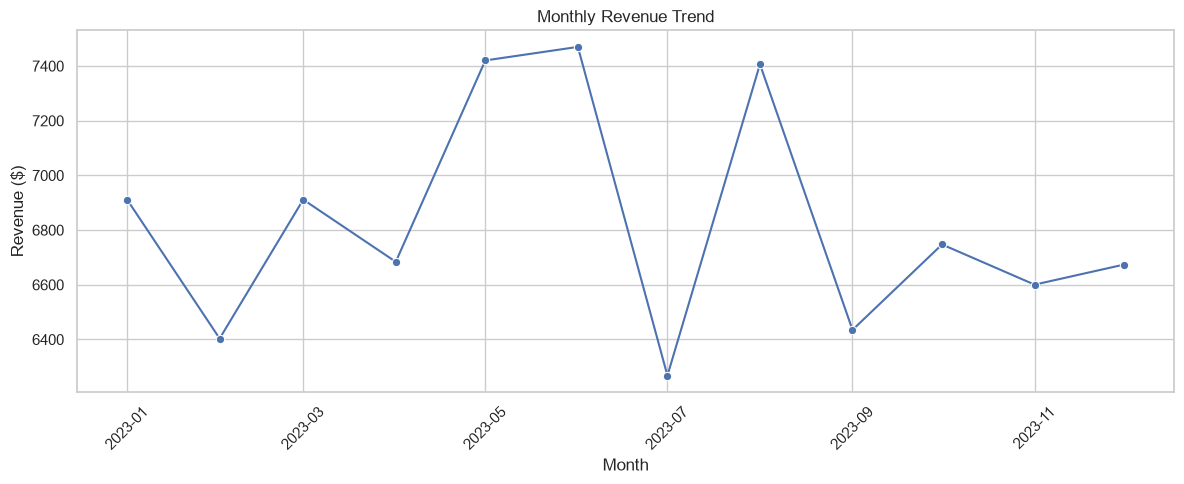

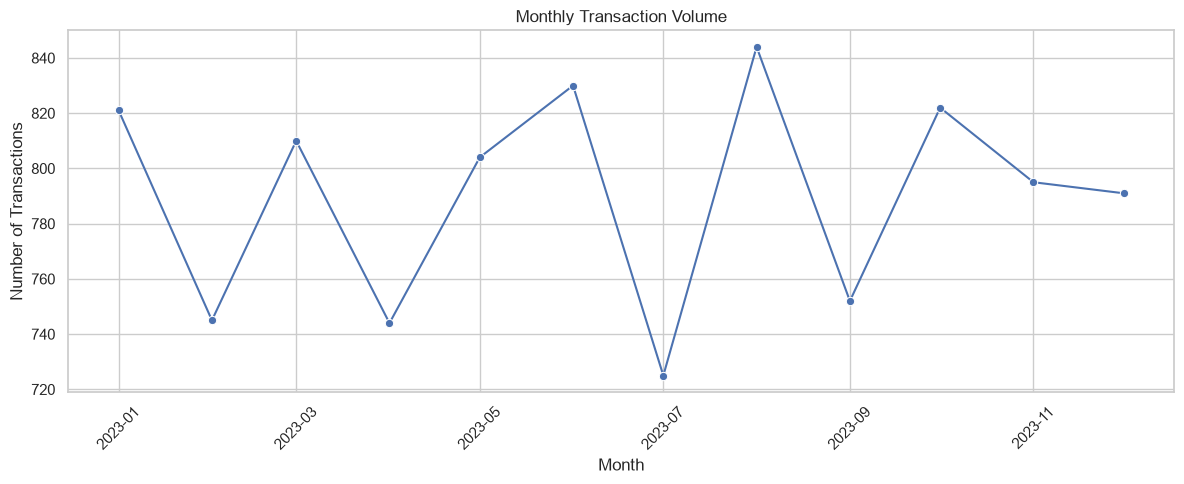

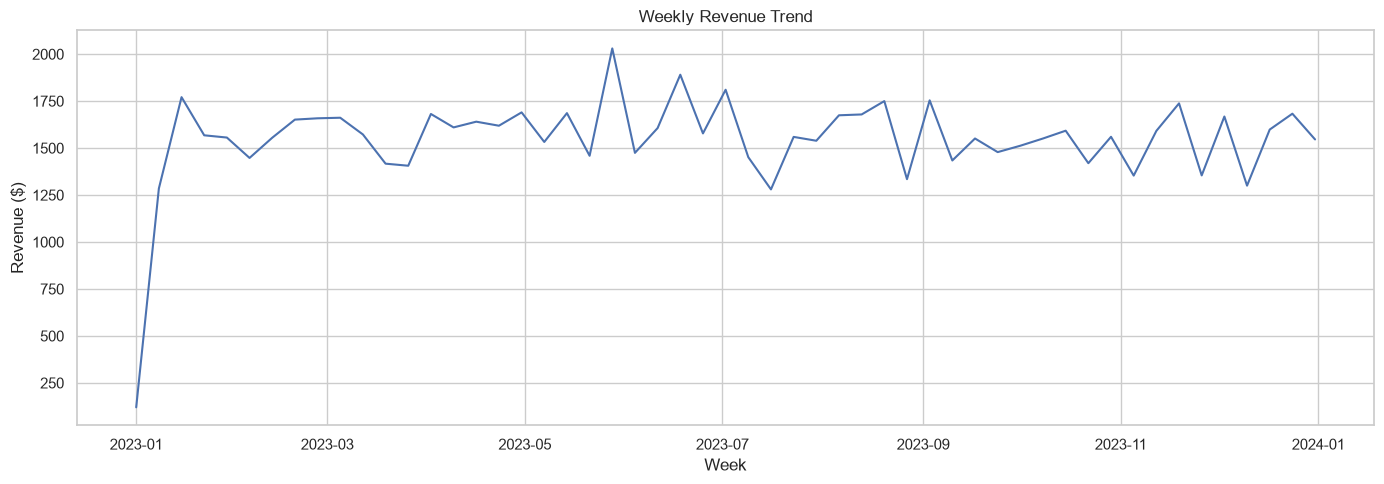

Sales Trend Summary
----------------------------------------
Highest revenue month: Jun 2023 ($7,470.00)
Lowest revenue month: Jul 2023 ($6,268.00)
Average monthly revenue: $6,827.71


In [7]:
# ── 2. Sales Trends Over Time ────────────────────────────────────────────────

# Ensure dates are datetime
df["Transaction Date"] = pd.to_datetime(df["Transaction Date"])

# Monthly aggregation
monthly_sales = (
    df.groupby(pd.Grouper(key="Transaction Date", freq="MS"))
    .agg(
        Revenue=("Total Spent", "sum"),
        Transactions=("Transaction ID", "count"),
        Units_Sold=("Quantity", "sum")
    )
    .reset_index()
)

# Weekly aggregation
weekly_sales = (
    df.groupby(pd.Grouper(key="Transaction Date", freq="W"))
    .agg(
        Revenue=("Total Spent", "sum"),
        Transactions=("Transaction ID", "count")
    )
    .reset_index()
)

# -------------------------
# Monthly Revenue Trend
# -------------------------
plt.figure(figsize=(12, 5))

sns.lineplot(
    data=monthly_sales,
    x="Transaction Date",
    y="Revenue",
    marker="o"
)

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue ($)")
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig(f"{CHARTS_DIR}/monthly_revenue_trend.png")
plt.show()

# -------------------------
# Monthly Transaction Volume
# -------------------------
plt.figure(figsize=(12, 5))

sns.lineplot(
    data=monthly_sales,
    x="Transaction Date",
    y="Transactions",
    marker="o"
)

plt.title("Monthly Transaction Volume")
plt.xlabel("Month")
plt.ylabel("Number of Transactions")
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig(f"{CHARTS_DIR}/monthly_transaction_volume.png")
plt.show()

# -------------------------
# Weekly Revenue Trend
# -------------------------
plt.figure(figsize=(14, 5))

sns.lineplot(
    data=weekly_sales,
    x="Transaction Date",
    y="Revenue"
)

plt.title("Weekly Revenue Trend")
plt.xlabel("Week")
plt.ylabel("Revenue ($)")
plt.tight_layout()

plt.savefig(f"{CHARTS_DIR}/weekly_revenue_trend.png")
plt.show()

# Summary statistics
print("Sales Trend Summary")
print("-" * 40)

best_month = monthly_sales.loc[monthly_sales["Revenue"].idxmax()]
worst_month = monthly_sales.loc[monthly_sales["Revenue"].idxmin()]

print(
    f"Highest revenue month: "
    f"{best_month['Transaction Date'].strftime('%b %Y')} "
    f"(${best_month['Revenue']:,.2f})"
)

print(
    f"Lowest revenue month: "
    f"{worst_month['Transaction Date'].strftime('%b %Y')} "
    f"(${worst_month['Revenue']:,.2f})"
)

print(
    f"Average monthly revenue: "
    f"${monthly_sales['Revenue'].mean():,.2f}"
)

## 3. Regional Performance

=== Regional Performance Summary ===
                 Province  Total_Revenue  Transactions  Units_Sold  Avg_Order_Value  Revenue_Share_%
         British Columbia        26998.0          3114        6247         8.669878            34.32
Newfoundland and Labrador        19709.0          2260        4501         8.720796            25.05
             Saskatchewan        16355.0          1876        3712         8.718017            20.79
                 Manitoba        15456.5          1819        3599         8.497251            19.65
                  Ontario          158.0            18          33         8.777778             0.20

=== Payment Method Revenue by Province ===
Payment Method               Cash  Credit Card  Digital Wallet
Province                                                      
British Columbia           6528.5      10556.5          8355.5
Manitoba                   3850.5       6342.0          4431.5
Newfoundland and Labrador  4773.0       7663.5          6187.

/var/folders/j9/p__0ry6s2gqdhm3jsd4f1d3h0000gn/T/ipykernel_29736/2382219380.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/var/folders/j9/p__0ry6s2gqdhm3jsd4f1d3h0000gn/T/ipykernel_29736/2382219380.py:62: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


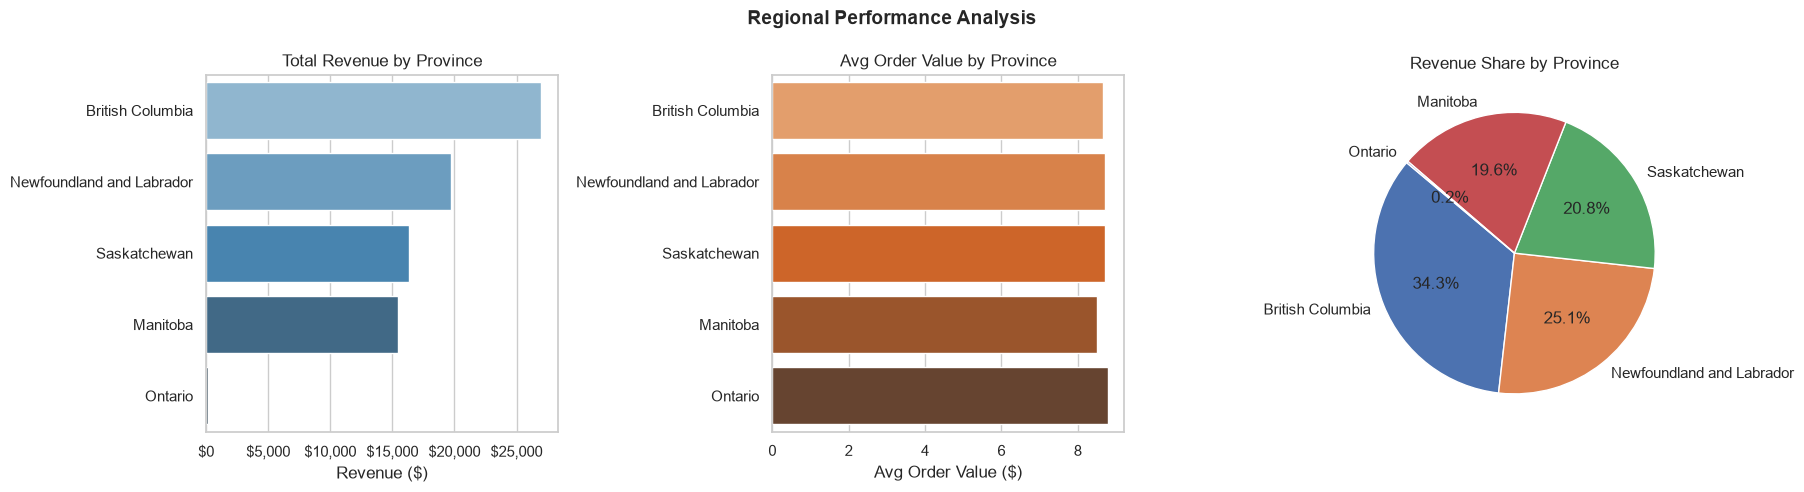

Chart saved → ../outputs/charts/regional_performance.png


In [8]:
# ── 3. Regional Performance ───────────────────────────────────────────────────

# Filter unknowns
regional_df = df[df["Province"] != "Unknown"].copy()

# Aggregate
regional_summary = (
    regional_df.groupby("Province")
    .agg(
        Total_Revenue   = ("Total Spent",      "sum"),
        Transactions    = ("Transaction ID",   "count"),
        Units_Sold      = ("Quantity",         "sum"),
        Avg_Order_Value = ("Total Spent",      "mean"),
    )
    .sort_values("Total_Revenue", ascending=False)
    .reset_index()
)
regional_summary["Revenue_Share_%"] = (
    regional_summary["Total_Revenue"] / regional_summary["Total_Revenue"].sum() * 100
).round(2)

print("=== Regional Performance Summary ===")
print(regional_summary.to_string(index=False))

# Payment method mix by province
payment_region = (
    regional_df[regional_df["Payment Method"] != "Unknown"]
    .groupby(["Province", "Payment Method"])["Total Spent"]
    .sum()
    .unstack(fill_value=0)
)
print("\n=== Payment Method Revenue by Province ===")
print(payment_region.to_string())

# Location type mix by province
location_region = (
    regional_df[regional_df["Location"] != "Unknown"]
    .groupby(["Province", "Location"])["Total Spent"]
    .sum()
    .unstack(fill_value=0)
)
print("\n=== Location Type Revenue by Province ===")
print(location_region.to_string())

# ── Charts ────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Regional Performance Analysis", fontsize=14, fontweight="bold")

# Total revenue
sns.barplot(
    data=regional_summary, y="Province", x="Total_Revenue",
    palette="Blues_d", ax=axes[0]
)
axes[0].set_title("Total Revenue by Province")
axes[0].set_xlabel("Revenue ($)")
axes[0].set_ylabel("")
axes[0].xaxis.set_major_formatter(
    plt.matplotlib.ticker.FuncFormatter(lambda x, _: f"${x:,.0f}")
)

# Avg order value
sns.barplot(
    data=regional_summary, y="Province", x="Avg_Order_Value",
    palette="Oranges_d", ax=axes[1]
)
axes[1].set_title("Avg Order Value by Province")
axes[1].set_xlabel("Avg Order Value ($)")
axes[1].set_ylabel("")

# Revenue share pie
axes[2].pie(
    regional_summary["Total_Revenue"],
    labels=regional_summary["Province"],
    autopct="%1.1f%%",
    startangle=140,
)
axes[2].set_title("Revenue Share by Province")

plt.tight_layout()
plt.savefig(CHARTS_DIR + "regional_performance.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart saved →", CHARTS_DIR + "regional_performance.png")


## 4. Product & Category Performance

In [ ]:
# ── 4. Product & Category Performance ────────────────────────────────────────

# Assign categories
category_map = {
    "Coffee": "Beverages", "Tea": "Beverages",
    "Refresher": "Beverages", "Juice": "Beverages",
    "Donut": "Food",  "Cookie": "Food",
    "Salad": "Food",  "Sandwich": "Food",
}
df["Category"] = df["Item"].map(category_map)

# Product-level summary
product_summary = (
    df.groupby("Item")
    .agg(
        Total_Revenue   = ("Total Spent",    "sum"),
        Units_Sold      = ("Quantity",       "sum"),
        Transactions    = ("Transaction ID", "count"),
        Avg_Price       = ("Price Per Unit", "mean"),
        Avg_Order_Value = ("Total Spent",    "mean"),
    )
    .sort_values("Total_Revenue", ascending=False)
    .reset_index()
)
product_summary["Revenue_Share_%"] = (
    product_summary["Total_Revenue"] / product_summary["Total_Revenue"].sum() * 100
).round(2)

print("=== Product Performance Summary ===")
print(product_summary.to_string(index=False))

# Category-level summary
category_summary = (
    df.groupby("Category")
    .agg(
        Total_Revenue = ("Total Spent",    "sum"),
        Units_Sold    = ("Quantity",       "sum"),
        Transactions  = ("Transaction ID", "count"),
    )
    .reset_index()
)
category_summary["Revenue_Share_%"] = (
    category_summary["Total_Revenue"] / category_summary["Total_Revenue"].sum() * 100
).round(2)

print("\n=== Category Performance Summary ===")
print(category_summary.to_string(index=False))

# Top product per province
top_by_province = (
    df.groupby(["Province", "Item"])["Total Spent"]
    .sum().reset_index()
    .sort_values(["Province", "Total Spent"], ascending=[True, False])
    .groupby("Province").first().reset_index()
    .rename(columns={"Item": "Top Item", "Total Spent": "Revenue"})
)
print("\n=== Top Product by Province ===")
print(top_by_province.to_string(index=False))

# ── Charts ────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle("Product & Category Performance", fontsize=14, fontweight="bold")

# Revenue by product
sns.barplot(
    data=product_summary, x="Item", y="Total_Revenue",
    palette="Blues_d", ax=axes[0, 0]
)
axes[0, 0].set_title("Total Revenue by Product")
axes[0, 0].set_ylabel("Revenue ($)")
axes[0, 0].set_xlabel("")
axes[0, 0].tick_params(axis="x", rotation=30)

# Units sold by product
sns.barplot(
    data=product_summary, x="Item", y="Units_Sold",
    palette="Greens_d", ax=axes[0, 1]
)
axes[0, 1].set_title("Units Sold by Product")
axes[0, 1].set_ylabel("Units Sold")
axes[0, 1].set_xlabel("")
axes[0, 1].tick_params(axis="x", rotation=30)

# Revenue share: Beverages vs Food
axes[1, 0].pie(
    category_summary["Total_Revenue"],
    labels=category_summary["Category"],
    autopct="%1.1f%%",
    startangle=90,
    colors=sns.color_palette("pastel")[:2],
)
axes[1, 0].set_title("Revenue Share: Beverages vs Food")

# Avg order value by product
sns.barplot(
    data=product_summary, x="Item", y="Avg_Order_Value",
    palette="Purples_d", ax=axes[1, 1]
)
axes[1, 1].set_title("Avg Order Value by Product")
axes[1, 1].set_ylabel("Avg Order Value ($)")
axes[1, 1].set_xlabel("")
axes[1, 1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.savefig(CHARTS_DIR + "product_category_performance.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart saved →", CHARTS_DIR + "product_category_performance.png")


## 5. Seasonal Patterns

=== Monthly Revenue & Transaction Count ===
Month_Name  Total_Revenue  Transactions
       Jan         6911.5           821
       Feb         6403.5           745
       Mar         6911.5           810
       Apr         6684.0           744
       May         7420.5           804
       Jun         7470.0           830
       Jul         6268.0           725
       Aug         7406.5           844
       Sep         6435.0           752
       Oct         6747.5           822
       Nov         6600.5           795
       Dec         6674.0           791

=== Quarterly Performance ===
Quarter  Total_Revenue  Transactions
     Q1        20226.5          2376
     Q2        21574.5          2378
     Q3        20109.5          2321
     Q4        20022.0          2408

=== Seasonal Performance ===
Season  Total_Revenue  Transactions
Winter        19989.0          2357
Spring        21016.0          2358
Summer        21144.5          2399
  Fall        19783.0          2369

=== Day-o

/var/folders/j9/p__0ry6s2gqdhm3jsd4f1d3h0000gn/T/ipykernel_29736/2123213588.py:85: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/var/folders/j9/p__0ry6s2gqdhm3jsd4f1d3h0000gn/T/ipykernel_29736/2123213588.py:95: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/var/folders/j9/p__0ry6s2gqdhm3jsd4f1d3h0000gn/T/ipykernel_29736/2123213588.py:108: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


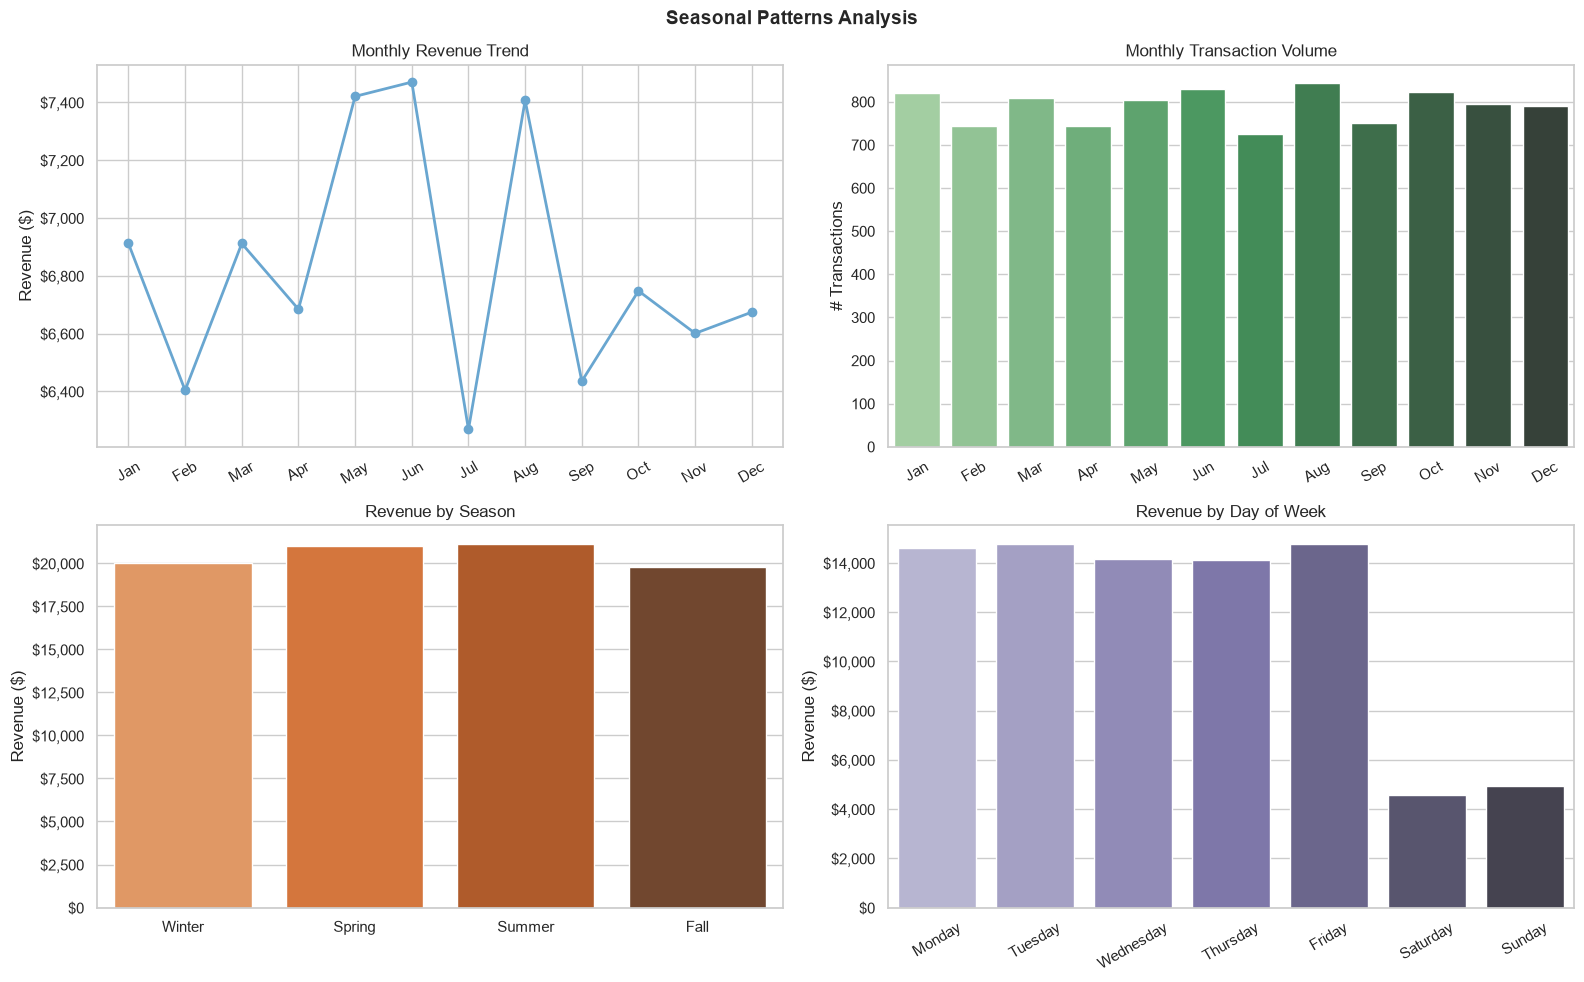

Chart saved → ../outputs/charts/seasonal_patterns.png


In [9]:
# ── 5. Seasonal Patterns ──────────────────────────────────────────────────────

# Derive time features
df["Month"]       = df["Transaction Date"].dt.month
df["Month_Name"]  = df["Transaction Date"].dt.strftime("%b")
df["Quarter"]     = df["Transaction Date"].dt.quarter
df["Day_of_Week"] = df["Transaction Date"].dt.day_name()

season_map = {
    12: "Winter", 1: "Winter", 2: "Winter",
     3: "Spring", 4: "Spring", 5: "Spring",
     6: "Summer", 7: "Summer", 8: "Summer",
     9: "Fall",  10: "Fall",  11: "Fall",
}
df["Season"] = df["Month"].map(season_map)

# Monthly summary
month_order = ["Jan","Feb","Mar","Apr","May","Jun",
               "Jul","Aug","Sep","Oct","Nov","Dec"]
monthly = (
    df.groupby("Month_Name")
    .agg(Total_Revenue=("Total Spent", "sum"), Transactions=("Transaction ID", "count"))
    .reindex(month_order).reset_index()
)
print("=== Monthly Revenue & Transaction Count ===")
print(monthly.to_string(index=False))

# Quarterly summary
quarterly = (
    df.groupby("Quarter")
    .agg(Total_Revenue=("Total Spent", "sum"), Transactions=("Transaction ID", "count"))
    .reset_index()
)
quarterly["Quarter"] = quarterly["Quarter"].map({1:"Q1",2:"Q2",3:"Q3",4:"Q4"})
print("\n=== Quarterly Performance ===")
print(quarterly.to_string(index=False))

# Seasonal summary
season_order = ["Winter", "Spring", "Summer", "Fall"]
seasonal = (
    df.groupby("Season")
    .agg(Total_Revenue=("Total Spent", "sum"), Transactions=("Transaction ID", "count"))
    .reindex(season_order).reset_index()
)
print("\n=== Seasonal Performance ===")
print(seasonal.to_string(index=False))

# Day-of-week summary
dow_order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
dow = (
    df.groupby("Day_of_Week")
    .agg(Total_Revenue=("Total Spent", "sum"), Transactions=("Transaction ID", "count"))
    .reindex(dow_order).reset_index()
)
print("\n=== Day-of-Week Performance ===")
print(dow.to_string(index=False))

# Top item per season
top_seasonal = (
    df.groupby(["Season", "Item"])["Total Spent"].sum().reset_index()
    .sort_values(["Season", "Total Spent"], ascending=[True, False])
    .groupby("Season").first().reset_index()
    .rename(columns={"Item": "Top Item", "Total Spent": "Revenue"})
)
print("\n=== Top Product by Season ===")
print(top_seasonal.to_string(index=False))

# ── Charts ────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle("Seasonal Patterns Analysis", fontsize=14, fontweight="bold")

# Monthly revenue trend
axes[0, 0].plot(
    monthly["Month_Name"], monthly["Total_Revenue"],
    marker="o", color=sns.color_palette("Blues_d")[1], linewidth=2
)
axes[0, 0].set_title("Monthly Revenue Trend")
axes[0, 0].set_ylabel("Revenue ($)")
axes[0, 0].tick_params(axis="x", rotation=30)
axes[0, 0].yaxis.set_major_formatter(
    plt.matplotlib.ticker.FuncFormatter(lambda x, _: f"${x:,.0f}")
)

# Monthly transaction volume
sns.barplot(
    data=monthly, x="Month_Name", y="Transactions",
    palette="Greens_d", ax=axes[0, 1]
)
axes[0, 1].set_title("Monthly Transaction Volume")
axes[0, 1].set_ylabel("# Transactions")
axes[0, 1].set_xlabel("")
axes[0, 1].tick_params(axis="x", rotation=30)

# Seasonal revenue
sns.barplot(
    data=seasonal, x="Season", y="Total_Revenue",
    palette="Oranges_d", ax=axes[1, 0],
    order=season_order
)
axes[1, 0].set_title("Revenue by Season")
axes[1, 0].set_ylabel("Revenue ($)")
axes[1, 0].set_xlabel("")
axes[1, 0].yaxis.set_major_formatter(
    plt.matplotlib.ticker.FuncFormatter(lambda x, _: f"${x:,.0f}")
)

# Day-of-week revenue
sns.barplot(
    data=dow, x="Day_of_Week", y="Total_Revenue",
    palette="Purples_d", ax=axes[1, 1],
    order=dow_order
)
axes[1, 1].set_title("Revenue by Day of Week")
axes[1, 1].set_ylabel("Revenue ($)")
axes[1, 1].set_xlabel("")
axes[1, 1].tick_params(axis="x", rotation=30)
axes[1, 1].yaxis.set_major_formatter(
    plt.matplotlib.ticker.FuncFormatter(lambda x, _: f"${x:,.0f}")
)

plt.tight_layout()
plt.savefig(CHARTS_DIR + "seasonal_patterns.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart saved →", CHARTS_DIR + "seasonal_patterns.png")


## 6. Business Insights Summary

Document each insight in the format: **Finding → Evidence → Recommended Action**

1. **Insight 1:** ...
2. **Insight 2:** ...
3. **Insight 3:** ...